In [1]:
#import cv2  # OpenCV library for reading videos
import numpy as np
import os
import dask.array as da
from stack_to_multiscale_ngff.h5_nested_store3 import H5_Nested_Store
import zarr
import matplotlib.pyplot as plt
import tifffile
import scipy.io as sio
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from flifile import FliFile
from numcodecs import Blosc
import json
from scipy.ndimage import zoom
from scipy.optimize import nnls
from joblib import Parallel, delayed
import numpy as np
from skimage.transform import warp, AffineTransform
from skimage.transform import resize
from holis_pipeline.utils.zarr_related import read_omehans, write_omehans, write_zarr, write_omehans_from_dask

In [54]:
def _safe_div(a: np.ndarray, b: np.ndarray, eps: float = 1e-6):
    return a / (b + eps)

def read_omehans(path_to_omehans, scale=None):
    location = os.path.join(path_to_omehans, f'scale{scale}' if scale else "")
    store = H5_Nested_Store(location)
    zarray = zarr.open(store)
    dask_zarray = da.array(zarray)
    return dask_zarray

def color_split(data_temp, center_pos=None):
    """
    Splits a 3D image splitter input into 4 cropped channels.
    Returns a 4D array with shape (ch, z, y, x)
    """
    ss = data_temp.shape  # (z, y, x)
    center_z = center_pos[0] if center_pos else ss[0] // 2
    center_y = center_pos[1] if center_pos else ss[1] // 2

    # Split
    temp_ch1 = data_temp[center_z:, center_y:, :]
    temp_ch2 = data_temp[center_z:, :center_y, :]
    temp_ch3 = data_temp[:center_z, center_y:, :]
    temp_ch4 = data_temp[:center_z, :center_y, :]

    # Compute minimum crop
    shapes = [ch.shape for ch in [temp_ch1, temp_ch2, temp_ch3, temp_ch4]]
    crop_z = min(s[0] for s in shapes)
    crop_y = min(s[1] for s in shapes)

    # Crop to match
    temp_ch1 = temp_ch1[:crop_z, :crop_y, :]
    temp_ch2 = temp_ch2[:crop_z, :crop_y, :]
    temp_ch3 = temp_ch3[:crop_z, :crop_y, :]
    temp_ch4 = temp_ch4[:crop_z, :crop_y, :]

    # Stack to (4, z, y, x)
    return da.stack([temp_ch1, temp_ch2, temp_ch3, temp_ch4], axis=0)

def subtract_background(input_location, output_location, bg_zy: np.ndarray):
    
    """
    Input: data .omehans (X,Z,Y), dark frames (.npy) (Z,Y) (1 file per nuclei+colors fli pair), dark frames will be broadcast across X 
    Output: .omehans (X,Z,Y) (and tiff or zarr if wanted) 
    """
    
    omehans_root = os.path.join(output_location, 'omehans')
    if os.path.exists(os.path.join(omehans_root, '0', '0', '0')):
        print("BG already subtracted previously")
        return
    
    print("Subtracting BG...")
    
    #####################
    # Numpy version
    # vol_xzy = read_omehans(input_location).compute().astype(np.float32)  # (X,Z,Y)
    # X, Z, Y = vol_xzy.shape
    # if bg_zy.shape != (Z, Y):
    #    raise ValueError(f"BG mask must be (Z,Y)={Z,Y}, got {bg_yz.shape}")
    # #bg = bg_zy.astype(np.float32) - 1024.0 
    # bg = bg_zy.astype(np.float32)
    # out = vol_xzy - bg  # broadcast over X
    # out = out[15000:16000,:,:]
    # #np.maximum(out, 0, out)
    #####################    
    
    #####################
    # Dask version
    vol_xzy = read_omehans(input_location).astype('float32')  # (X,Z,Y)
    X, Z, Y = vol_xzy.shape
    if bg_zy.shape != (Z, Y):
        raise ValueError(f"BG mask must be (Z,Y)={Z,Y}, got {bg_zy.shape}")
    bg_zy_d = da.from_array(bg_zy, chunks=(vol_xzy.chunks[1], vol_xzy.chunks[2])).astype('float32') #- 1024.0
    #out = da.maximum(vol_xzy.astype('float32') - bg_zy_d[None, :, :], 0)
    out = vol_xzy.astype('float32') - bg_zy_d[None, :, :]
    out = out[15000:15100,:,:]
    #####################
    
    # Save
    try:
        #write_omehans(omehans_root, _clip16(out))           #Use when using numpy version
        write_omehans_from_dask(omehans_root, da.clip(out, 0, 65535).astype('uint16')) 
    except zarr.errors.ContainsArrayError:
        print(".omehans array already exists")
    #try:
    #    write_zarr(os.path.join(output_location, 'zarr'), _clip16(out))
    #except zarr.errors.ContainsArrayError:
    #    print(".zarr array already exists")

    # Save tiff
    os.makedirs(output_location, exist_ok=True)
    path_to_tiff = os.path.join(output_location, "bg_subtracted.tif")
    tifffile.imwrite(path_to_tiff, out.astype('uint16').compute())
    
    print("Saved BG-subtracted file")

    return out

def laser_correction_nuclei(input_location, output_location, pattern_zy):
    """
    Input:
        - flattened .omehans (X,Z,Y)
        - laser pattern matrix (Z,Y)
    Output: corrected .omehans the same shape as input
    """

    root = os.path.join(output_location, 'omehans')
    if os.path.exists(os.path.join(root, '0', '0', '0')):
        print("Laser pattern corrected (nuclei) previously")
        return

    print("Laser correction (nuclei): XZY vol ÷ ZY pattern")
    img = read_omehans(os.path.join(input_location, "omehans")).compute().astype(np.float32)  # (X,Z,Y)
    X, Z, Y = img.shape
    pat = pattern_zy.astype(np.float32)

    #ff_corr = _safe_div(img, ff)
    #corr = _safe_div(ff_corr, pat)
    corr = _safe_div(img, pat)

    # Save
    # try:
    #     write_omehans(root, _clip16(corr))
    # except zarr.errors.ContainsArrayError:
    #     print(".omehans already exists")
    #try:
    #    write_zarr(os.path.join(output_location, 'zarr'), _clip16(corr))
    #except zarr.errors.ContainsArrayError:
    #    print(".zarr already exists")

    # Save tiff
    os.makedirs(output_location, exist_ok=True)
    path_to_tiff = os.path.join(output_location, "laser_corrected.tif")
    tifffile.imwrite(path_to_tiff, corr.astype('uint16'))
    print("Saved laser-pattern-corrected (nuclei) file")

    return corr

def laser_correction_colors(input_location, output_location, pattern_czy, center_pos=None):
    """
    Laser correction for color splitter data.

    input_location:  folder with raw colors 'omehans' (X,Z,Y)
    output_location: where corrected 4-channel omehans will be written
    pattern_czy:     np.ndarray of shape (C=4, Zc, Yc) final mixed patterns
    center_pos:      (cz, cy) in (Z,Y); if None, use midpoints
    """

    root = os.path.join(output_location, "omehans")
    # if corrected already present, skip
    if os.path.exists(os.path.join(root, "0", "0", "0")):
        print("Laser pattern corrected (colors) previously")
        return

    print("Laser correction (colors): split (X,Z,Y) -> (C,X,Zc,Yc) and divide by (C,Zc,Yc) pattern")

    # 1) load raw splitter volume (X,Z,Y)
    vol = read_omehans(os.path.join(input_location, "omehans")).compute().astype(np.float32)
    X, Z, Y = vol.shape

    # 2) split into 4 quadrants in (Z,Y), same as your split_color_channels
    if center_pos is not None:
        cz, cy = int(center_pos[0]), int(center_pos[1])
    else:
        cz, cy = Z // 2, Y // 2

    ch1 = vol[:, :cz, :cy]
    ch2 = vol[:, cz:, :cy]
    ch3 = vol[:, :cz, cy:]
    ch4 = vol[:, cz:, cy:]

    # crop to common min size along Z/Y
    Zc = min(ch1.shape[1], ch2.shape[1], ch3.shape[1], ch4.shape[1])
    Yc = min(ch1.shape[2], ch2.shape[2], ch3.shape[2], ch4.shape[2])
    chs = [c[:, :Zc, :Yc] for c in (ch1, ch2, ch3, ch4)]
    # (4, X, Zc, Yc)
    colors_cxzy = np.stack(chs, axis=0).astype(np.float32)

    # 3) check pattern and divide
    pat = np.asarray(pattern_czy, dtype=np.float32)
    if pat.ndim != 3 or pat.shape[0] != colors_cxzy.shape[0] or pat.shape[1:] != (Zc, Yc):
        raise ValueError(
            f"pattern_czy must be (C,Zc,Yc) matching split volume; "
            f"got {pat.shape}, expected ({colors_cxzy.shape[0]},{Zc},{Yc})"
        )

    # broadcast pattern over X: (C,1,Zc,Yc) → (C,X,Zc,Yc)
    pat_cxzy = pat[:, None, :, :]
    corr = _safe_div(colors_cxzy, pat_cxzy)  # same helper as nuclei

    # 4) save corrected 4-channel omehans
    # try:
    #     write_omehans(root, _clip16(corr))   # corr shape (4,X,Zc,Yc)
    # except zarr.errors.ContainsArrayError:
    #     print(".omehans already exists (colors, corrected)")

    # optional zarr, like in split_color_channels
    #write_zarr(os.path.join(output_location, "zarr"), _clip16(corr))
    
    # Save tiff
    os.makedirs(output_location, exist_ok=True)
    path_to_tiff = os.path.join(output_location, "laser_corrected.tif")
    tifffile.imwrite(path_to_tiff, corr.astype('uint16'))

    print("Saved laser-pattern-corrected colors (C=4, X, Zc, Yc)")

    return corr


#### Load correction matrices, BG and patterns

In [3]:
# Path defs
#correction_path = "/bil/proj/rf1hillman/results/2025_06_15_NPBB328_surface_corrections/"
correction_path_bg = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/correction_files/'
correction_path_lasers = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/correction_files/laser_patterns/'

out_path_BG_nuclei = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/out_processed_z1y7test/bg_corrected_nuclei/'
out_path_BG_colors = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/out_processed_z1y7test/bg_corrected_colors/'
out_path_lasers_nuclei = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/out_processed_z1y7test/laser_corrected_nuclei/'
out_path_lasers_colors = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/out_processed_z1y7test/laser_corrected_colors/'

# Bg and laser pattern load
corr_BG_nuclei = np.load(os.path.join(correction_path_bg, "bg_nuclei_mask_z01.npy"))
corr_BG_colors = np.load(os.path.join(correction_path_bg, "bg_colors_mask_z01.npy"))

laser_correction_Nuclei_pattern = np.load(os.path.join(correction_path_lasers, "laser_pattern_nuclei_mask_z01_final.npy"))
laser_correction_Colors_pattern = np.load(os.path.join(correction_path_lasers, "laser_pattern_colors_mask_z01_final.npy"))

#### Load run

In [26]:
slab_path = '/bil/proj/rf1hillman/results/NPBB328_Cortex/Slab6/'
location_nuclei = os.path.join(slab_path, 'NPBB328-Cortex-Slab06-run051-z01-y050-Exc-488nm-561nm-594nm-660nm_HiCAM FLUO_1875-ST-272.fli.zst')
location_colors = os.path.join(slab_path, 'NPBB328-Cortex-Slab06-run051-z01-y050-Exc-488nm-561nm-594nm-660nm_HiCAM FLUO_1875-ST-088.fli.zst')
im_nuclei = read_omehans(location_nuclei)
im_colors = read_omehans(location_colors)

#### Correct for background and laser pattern

In [5]:
print(f'corr_BG_nuclei is {corr_BG_nuclei.shape}')
print(f'corr_BG_colors is {corr_BG_colors.shape}')

corr_BG_nuclei is (1024, 1280)
corr_BG_colors is (1024, 1280)


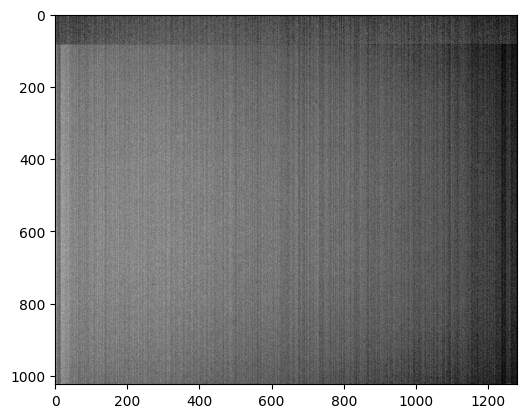

In [6]:
plt.imshow(corr_BG_nuclei, cmap='Greys', vmax=2000)

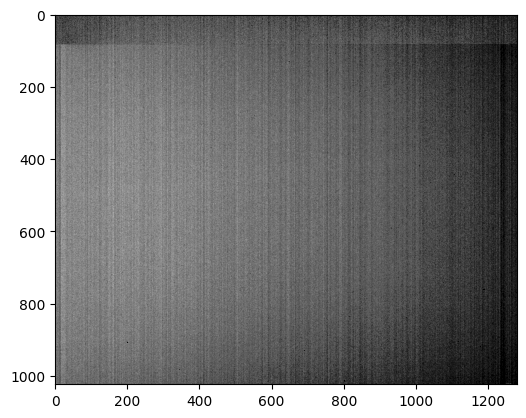

In [7]:
plt.imshow(corr_BG_colors, cmap='Greys', vmax=2000)

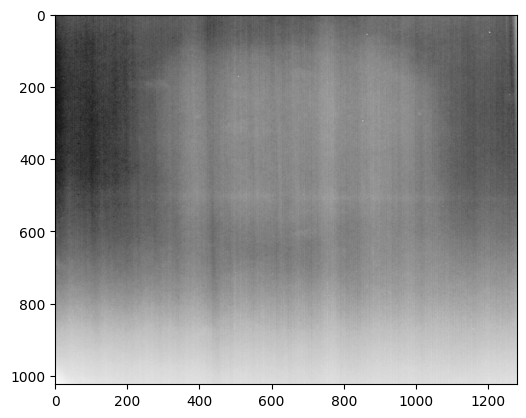

In [16]:
plt.imshow(laser_correction_Nuclei_pattern, cmap='Greys')

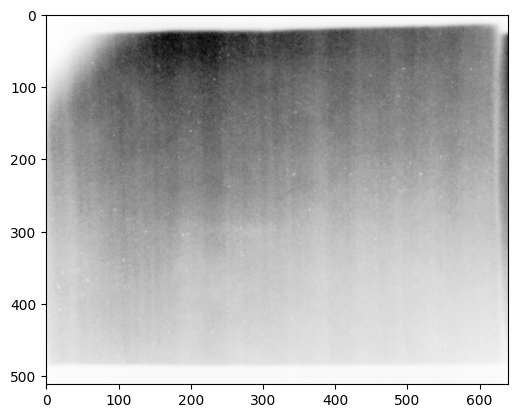

In [22]:
plt.imshow(laser_correction_Colors_pattern[0], cmap='Greys')

In [50]:
# Bg correction

im_nuclei_bg_corr = subtract_background(location_nuclei, out_path_BG_nuclei, corr_BG_nuclei)
im_colors_bg_corr = subtract_background(location_colors, out_path_BG_colors, corr_BG_colors)

print(f'im_nuclei_bg_corr has shape {im_nuclei_bg_corr.shape}')
print(f'im_colors_bg_corr has shape {im_colors_bg_corr.shape}')

Subtracting BG...
Saving .omehans array
Saved BG-subtracted file
Subtracting BG...
Saving .omehans array
Saved BG-subtracted file
im_nuclei_bg_corr has shape (100, 1024, 1280)
im_colors_bg_corr has shape (100, 1024, 1280)


In [56]:
# Laser pattern correction

im_nuclei_laser_corr = laser_correction_nuclei(
        str(out_path_BG_nuclei),
        str(out_path_lasers_nuclei),
        laser_correction_Nuclei_pattern
    )

transforms = sio.loadmat("/bil/proj/rf1hillman/HOLiS_NPBB328_Cortex/Matlab_info/NPBB328_colorMerge_transforms.mat")
center_raw = transforms['CenterSplitPosition'] 
center_arr = np.atleast_1d(center_raw).astype(int).ravel()
centerPos = (int(center_arr[0]), int(center_arr[1]))  

im_colors_laser_corr = laser_correction_colors(
        str(out_path_BG_colors),
        str(out_path_lasers_colors),
        laser_correction_Colors_pattern,
        centerPos
    )

print(f'im_nuclei_laser_corr has shape {im_nuclei_laser_corr.shape}')
print(f'im_colors_laser_corr has shape {im_colors_laser_corr.shape}')

Laser correction (nuclei): XZY vol ÷ ZY pattern
Saved laser-pattern-corrected (nuclei) file
Laser correction (colors): split (X,Z,Y) -> (C,X,Zc,Yc) and divide by (C,Zc,Yc) pattern
Saved laser-pattern-corrected colors (C=4, X, Zc, Yc)
im_nuclei_laser_corr has shape (100, 1024, 1280)
im_colors_laser_corr has shape (4, 100, 512, 640)


#### Color split

In [8]:
# Load registration transforms
transforms = sio.loadmat(os.path.join(f'/bil/proj/rf1hillman/2025_06_26_NPBB328_surface_processingMatlabCode_SLURM/NPBB328_colorMerge_transforms.mat')) 

In [9]:
im_nuclei_corr_zyx = np.transpose(im_colors_corr, (1, 2, 0))
im_colors_corr_zyx = np.transpose(im_colors_corr, (1, 2, 0))

center_split_position = list([transforms['CenterSplitPosition'][0][0], transforms['CenterSplitPosition'][0][1]])
im_colors_corr_zyx_split = color_split(im_colors_corr_zyx, center_split_position)
print(f'im_colors_corr_split has shape {im_colors_corr_zyx_split.shape}')

im_colors_corr_split has shape (4, 486, 640, 36000)


In [10]:
print(im_nuclei_corr_zyx.shape)

(1024, 1280, 36000)


In [ ]:
target_shape = im_colors_corr_zyx_split.shape[1:]  # skip channel dim
print(f'Target shape is {target_shape}')

im_nuclei_corr_zyx_rescaled = resize(
    im_nuclei_corr_zyx,
    output_shape=target_shape,
    order=1,              # bilinear interpolation
    preserve_range=True,  # don't normalize intensity
    anti_aliasing=True
).astype(np.float32)

print(f'im_nuclei_corr_zyx_rescaled shpae is {im_nuclei_corr_zyx_rescaled.shape}')

Target shape is (486, 640, 36000)


In [ ]:
import numpy as np
import torch
import kornia

def to_affine_batch(matrix, batch_size):
    """Convert 3x3 affine to Kornia-compatible (B, 2, 3)"""
    M = torch.tensor(matrix[:2, :], dtype=torch.float32)
    M_batch = M.unsqueeze(0).repeat(batch_size, 1, 1)  # (B, 2, 3)
    return M_batch

def register_channel_stack_kornia(stack_zyx, transform_matrix, device="cuda", batch_size=128):
    """
    Apply 2D affine transform to every (Z,Y) slice at each X using mini-batching.
    Kornia expect the batching dimension (here X) to follow the batch size (here B), hence the transpose.
    """
    if not isinstance(stack_zyx, np.ndarray):
        stack_zyx = np.array(stack_zyx)

    Z, Y, X = stack_zyx.shape
    stack_xzy = np.transpose(stack_zyx, (2, 0, 1))  # (X, Z, Y)

    output = np.zeros((X, Z, Y), dtype=np.float32)  # Will hold all warped slices

    for i in tqdm(range(0, X, batch_size), desc="Warping batches"):
        end = min(i + batch_size, X)
        batch = torch.from_numpy(stack_xzy[i:end].copy()).unsqueeze(1).float().to(device)  # (B, 1, Z, Y)

        M = torch.tensor(transform_matrix[:2, :], dtype=torch.float32).unsqueeze(0).repeat(end - i, 1, 1).to(device)

        warped = kornia.geometry.transform.warp_affine(
            batch, M, dsize=(Z, Y), align_corners=False
        )  # (B, 1, Z, Y)

        output[i:end] = warped.squeeze(1).cpu().numpy()

    return np.transpose(output, (1, 2, 0))  # (Z, Y, X)

# === INPUT DATA ===
# Assume the following variables are loaded:
# im_nuclei_corr_zyx: shape (Z, Y, X)
# im_colors_corr_zyx: shape (4, Z, Y, X)
# transforms['Transforms'][0][0][ch]: each a 3x3 or object-like affine matrix
# correction_path: output directory

z, y, x = im_colors_corr_zyx_split.shape[1:]
volReg = np.zeros((5, z, y, x), dtype=np.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"

for ch in range(5):
    print(f"Registering channel {ch}")

    # Extract and convert transform matrix
    #raw = transforms['Transforms'][0][0][ch]

    print("Transforms type:", type(transforms['Transforms']))
    print("Transforms shape:", np.shape(transforms['Transforms']))
    print("Transforms dtype:", transforms['Transforms'].dtype)
    print("Transforms content preview:", transforms['Transforms'])


    transform_matrix = transforms['Transforms'][0][ch]['A2D'].astype(np.float32)

    print(type(transform_matrix))           # <class 'tuple'>
    print(type(transform_matrix[0]))        # <class 'numpy.ndarray'>
    print(transform_matrix[0].shape) 

    print(f'Transform_matrix shape is: {transform_matrix.shape}')

    #M = np.array(raw.toarray() if hasattr(raw, "toarray") else raw).astype(np.float32)
    M = transform_matrix

    # Get stack to transform
    if ch == 0:
        #stack = np.rot90(np.rot90(im_nuclei_corr_zyx_rescaled, axes=(0, 1)), axes=(0, 1))  # rotate 180°
        stack = np.rot90(im_nuclei_corr_zyx_rescaled, k=2, axes=(0, 1))
        print(f'Stack shape is {stack.shape}')
    else:
        stack = im_colors_corr_zyx_split[ch - 1]
        print(f'Stack shape is {stack.shape}')

    # Apply batch warp
    volReg[ch] = register_channel_stack_kornia(stack, M, device=device)

# Save subset of result
print('Saving registered volume')
np.save(correction_path + "volReg.npy", volReg[:, :, :, 15000:16000])

Registering channel 0


### Spectral Unmixing

In [ ]:
# Assume volReg has shape (5, Z, Y, X)
simulation_matrices = sio.loadmat('/bil/proj/rf1hillman/2024_07_29_AI7_EH5k_human_finalMarkerCombination_100mm/code_Matlab/SimulationMatrices_equalPower_firstHemibrain')# Fluorophore x Channel matrix normalization
Flch = simulation_matrices['Flch']
Flch_rel = Flch.copy()
# Normalize along columns - so each entry (i,j) is the percentage of the signal in channel j coming from fluorophore i
Flch_rel = Flch_rel / np.sum(Flch_rel, axis=1, keepdims=True)
M_inv = np.linalg.inv(Flch_rel)

ss = volReg.shape  # (5, Z, Y, X)
volReg_flat = volReg.reshape(ss[0], -1)  # shape: (5, Z*Y*X)
volReg_unmixed_flat = M_inv.T @ volReg_flat  # shape: (5, Z*Y*X)
volReg_unmixed = volReg_um_flat.reshape(ss) 